# Day 3 Hands-On — Statistics + Probability + SQL

# STATISTICS

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sqlite3

## Create Sample Data

In [2]:
data = np.array([12, 15, 18, 20, 22, 25, 25, 27, 30, 35, 40, 100])
data

array([ 12,  15,  18,  20,  22,  25,  25,  27,  30,  35,  40, 100])

## Mean / Median / Mode

In [3]:
print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Mode:", stats.mode(data, keepdims=True))

Mean: 30.75
Median: 25.0
Mode: ModeResult(mode=array([25]), count=array([2]))


## Range / Variance / Standard Deviation

In [4]:
print("Range:", np.max(data) - np.min(data))
print("Population Variance:", np.var(data))
print("Sample Variance:", np.var(data, ddof=1))
print("Population SD:", np.std(data))
print("Sample SD:", np.std(data, ddof=1))

Range: 88
Population Variance: 494.5208333333333
Sample Variance: 539.4772727272727
Population SD: 22.23782438399344
Sample SD: 23.22665005392023


## Quartiles / IQR / Outliers

In [5]:
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = data[(data < lower) | (data > upper)]

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)
print("IQR:", iqr)
print("Outliers:", outliers)

Q1: 19.5
Q2: 25.0
Q3: 31.25
IQR: 11.75
Outliers: [100]


## Percentiles / Z-Scores / Coefficient of Variation

In [10]:
print(np.percentile(data, [10, 25, 50, 75, 90]))
print("z-score:\n",stats.zscore(data))
print("CV:\n", np.std(data, ddof=1) / np.mean(data) * 100)

[15.3  19.5  25.   31.25 39.5 ]
z-score:
 [-0.84315802 -0.70825274 -0.57334745 -0.4834106  -0.39347374 -0.25856846
 -0.25856846 -0.1686316  -0.03372632  0.19111582  0.41595796  3.11406362]
CV:
 75.53382131356172


## Normal Distribution

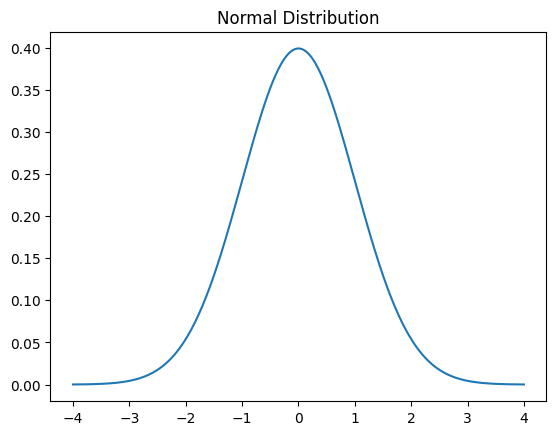

In [11]:
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)

plt.plot(x, y)
plt.title("Normal Distribution")
plt.show()

## Uniform Distribution

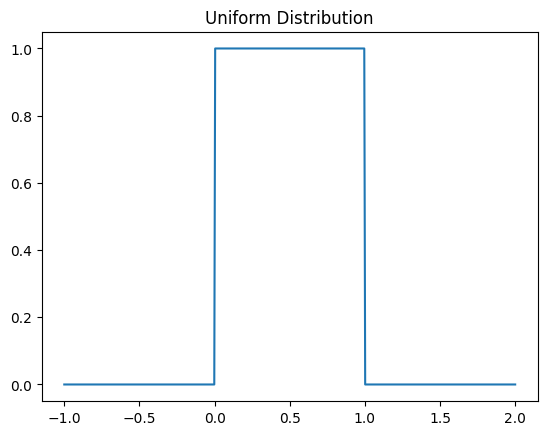

In [12]:
x = np.linspace(-1, 2, 500)
y = stats.uniform.pdf(x, loc=0, scale=1)

plt.plot(x, y)
plt.title("Uniform Distribution")
plt.show()

## Bernoulli Distribution

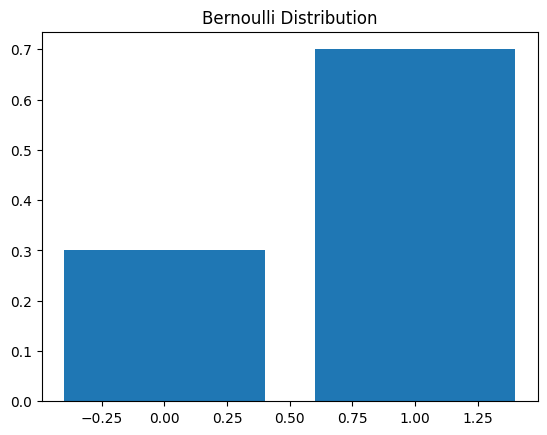

In [13]:
p = 0.7
x = np.array([0, 1])
y = stats.bernoulli.pmf(x, p)

plt.bar(x, y)
plt.title("Bernoulli Distribution")
plt.show()

## Binomial Distribution

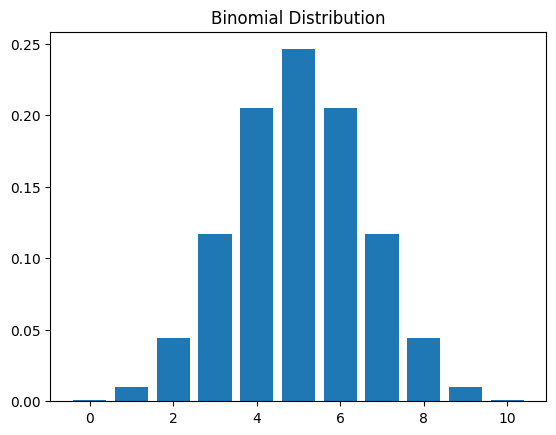

In [14]:
n, p = 10, 0.5
x = np.arange(n + 1)
y = stats.binom.pmf(x, n, p)

plt.bar(x, y)
plt.title("Binomial Distribution")
plt.show()

## Poisson Distribution

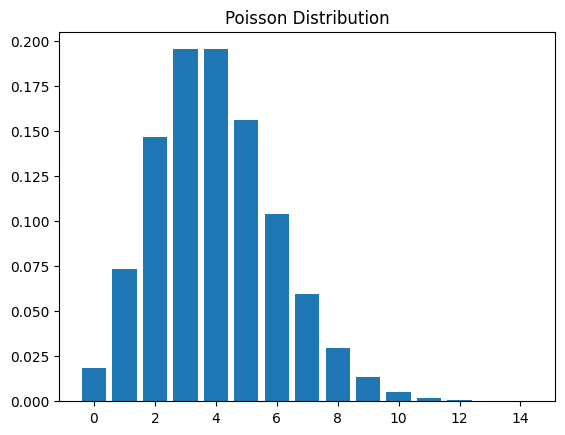

In [15]:
lam = 4
x = np.arange(15)
y = stats.poisson.pmf(x, lam)

plt.bar(x, y)
plt.title("Poisson Distribution")
plt.show()

## Exponential Distribution

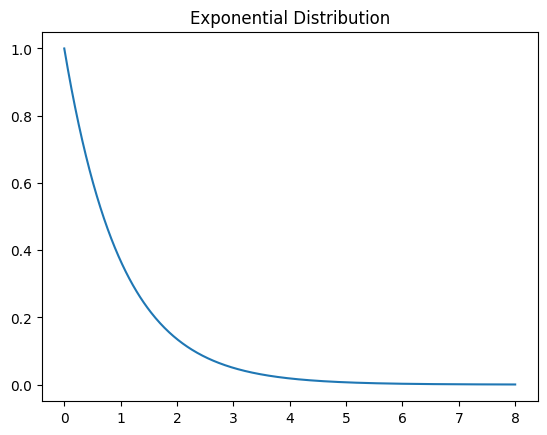

In [16]:
lam = 1
x = np.linspace(0, 8, 500)
y = stats.expon.pdf(x, scale=1/lam)

plt.plot(x, y)
plt.title("Exponential Distribution")
plt.show()

## Skewness / Kurtosis

In [17]:
right_skewed = np.random.exponential(scale=2, size=1000)
left_skewed = -np.random.exponential(scale=2, size=1000)
normal_data = np.random.normal(size=1000)

print("Right skew:", stats.skew(right_skewed))
print("Left skew:", stats.skew(left_skewed))
print("Normal kurtosis:", stats.kurtosis(normal_data))

Right skew: 1.727618988090446
Left skew: -2.2113000553878424
Normal kurtosis: 0.05972352735802078


# PROBABILITY

## Basic Probability

In [20]:
favourable = 2
total = 6
print(favourable / total)

0.3333333333333333


## Complement Rule

In [21]:
p_a = 0.35
print(1 - p_a)

0.65


## Addition Rule

In [22]:
p_a = 0.4
p_b = 0.5
p_a_and_b = 0.2

print(p_a + p_b - p_a_and_b)

0.7


## Multiplication Rule

In [23]:
p_a = 0.5
p_b = 0.4

print(p_a * p_b)

0.2


## Conditional Probability

In [24]:
p_a_and_b = 0.2
p_b = 0.5

print(p_a_and_b / p_b)

0.4


## Bayes' Theorem

In [25]:
p_disease = 0.01
p_pos_given_disease = 0.95
p_pos_given_no_disease = 0.05
p_no_disease = 1 - p_disease

p_positive = (
    p_pos_given_disease * p_disease
    + p_pos_given_no_disease * p_no_disease
)

posterior = p_pos_given_disease * p_disease / p_positive
posterior

0.16101694915254236

## Expected Value / Variance of Random Variable

In [26]:
values = np.array([0, 1, 2, 3])
probs = np.array([0.1, 0.3, 0.4, 0.2])

expected_value = np.sum(values * probs)
expected_x2 = np.sum((values ** 2) * probs)
variance = expected_x2 - expected_value ** 2

print("Expected Value:", expected_value)
print("Variance:", variance)

Expected Value: 1.7000000000000002
Variance: 0.8099999999999996


## Distribution Means and Variances

In [27]:
p = 0.7
print("Bernoulli mean:", p)
print("Bernoulli variance:", p * (1-p))

n, p = 20, 0.4
print("Binomial mean:", n*p)
print("Binomial variance:", n*p*(1-p))

lam = 5
print("Poisson mean:", lam)
print("Poisson variance:", lam)

lam = 2
print("Exponential mean:", 1/lam)

Bernoulli mean: 0.7
Bernoulli variance: 0.21000000000000002
Binomial mean: 8.0
Binomial variance: 4.8
Poisson mean: 5
Poisson variance: 5
Exponential mean: 0.5


## Covariance / Pearson / Spearman

In [29]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 8, 10])

print("Covariance matrix:")
print(np.cov(x, y))
print("Pearson: \n", stats.pearsonr(x, y))
print("Spearman: \n", stats.spearmanr(x, y))

Covariance matrix:
[[ 2.5  5. ]
 [ 5.  10.2]]
Pearson: 
 PearsonRResult(statistic=np.float64(0.9901475429766744), pvalue=np.float64(0.0011722164447168705))
Spearman: 
 SignificanceResult(statistic=np.float64(0.9999999999999999), pvalue=np.float64(1.4042654220543672e-24))


## Simple Random Sampling

In [30]:
population = np.arange(1, 101)
sample = np.random.choice(population, size=10, replace=False)
sample

array([17, 43, 18, 11, 23, 55, 19, 78, 61, 76])

## Systematic Sampling

In [31]:
population = np.arange(1, 101)
systematic_sample = population[::10]
systematic_sample

array([ 1, 11, 21, 31, 41, 51, 61, 71, 81, 91])

## Stratified Sampling

In [32]:
df_sample = pd.DataFrame({
    "Group": ["A"] * 50 + ["B"] * 30 + ["C"] * 20,
    "Value": np.random.randn(100)
})

stratified_sample = (
    df_sample.groupby("Group", group_keys=False)
    .sample(frac=0.2, random_state=42)
)

stratified_sample["Group"].value_counts()

,count
Group,
A,10
B,6
C,4


## Cluster Sampling

In [33]:
df_cluster = pd.DataFrame({
    "Cluster": np.repeat(["C1", "C2", "C3", "C4"], 25),
    "Value": np.random.randn(100)
})

cluster_sample = df_cluster[
    df_cluster["Cluster"].isin(["C1", "C3"])
]

cluster_sample.head()

,Cluster,Value
0,C1,0.154065
1,C1,-1.824878
2,C1,0.529880
3,C1,0.346704
4,C1,1.707429


## Central Limit Theorem

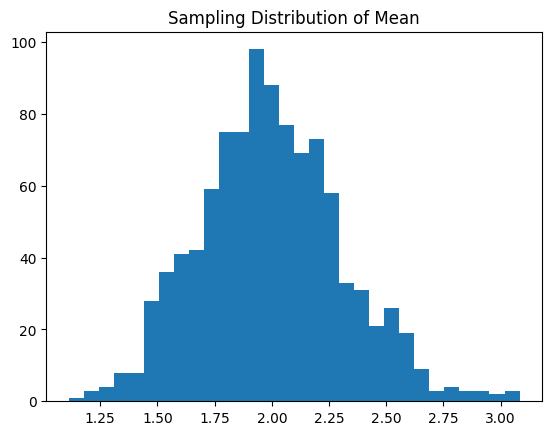

In [34]:
population = np.random.exponential(scale=2, size=100000)
sample_means = []

for _ in range(1000):
    sample = np.random.choice(population, size=40)
    sample_means.append(np.mean(sample))

plt.hist(sample_means, bins=30)
plt.title("Sampling Distribution of Mean")
plt.show()

## Standard Error / Confidence Interval

In [35]:
sample = np.random.normal(loc=50, scale=10, size=100)

se = stats.sem(sample)
ci = stats.t.interval(
    confidence=0.95,
    df=len(sample)-1,
    loc=np.mean(sample),
    scale=se
)

print("SE:", se)
print("95% CI:", ci)

SE: 0.9511276021646939
95% CI: (np.float64(50.349312329798806), np.float64(54.123799352324795))


## One-Sample T-Test

In [36]:
sample = np.array([51, 49, 52, 48, 50, 53, 47, 51, 49, 52])
stats.ttest_1samp(sample, popmean=50)

TtestResult(statistic=np.float64(0.32732683535399315), pvalue=np.float64(0.7509058687700327), df=np.int64(9))

## Independent T-Test

In [37]:
group_a = np.array([78, 82, 85, 79, 88, 90])
group_b = np.array([72, 75, 70, 74, 76, 73])

stats.ttest_ind(group_a, group_b)

TtestResult(statistic=np.float64(4.7720553065048685), pvalue=np.float64(0.0007547068997750336), df=np.float64(10.0))

## Paired T-Test

In [38]:
before = np.array([60, 65, 70, 68, 72])
after = np.array([66, 68, 75, 72, 78])

stats.ttest_rel(before, after)

TtestResult(statistic=np.float64(-8.231932086840425), pvalue=np.float64(0.0011873593006288521), df=np.int64(4))

## Chi-Square Test

In [39]:
observed = np.array([
    [30, 20],
    [15, 35]
])

stats.chi2_contingency(observed)

Chi2ContingencyResult(statistic=np.float64(7.919191919191919), pvalue=np.float64(0.004891311452359333), dof=1, expected_freq=array([[22.5, 27.5],
       [22.5, 27.5]]))

## ANOVA

In [40]:
group_1 = [12, 14, 13, 15, 16]
group_2 = [18, 17, 19, 20, 18]
group_3 = [22, 21, 23, 24, 22]

stats.f_oneway(group_1, group_2, group_3)

F_onewayResult(statistic=np.float64(51.92156862745097), pvalue=np.float64(1.2355650442192842e-06))

## P-Value Decision

In [41]:
alpha = 0.05
p_value = 0.03

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


# SQL



## Create SQLite Database

In [47]:
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

## Create Tables

In [48]:
cursor.execute("""
CREATE TABLE departments (
    department_id INTEGER PRIMARY KEY,
    department_name TEXT UNIQUE
)
""")

cursor.execute("""
CREATE TABLE employees (
    employee_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    age INTEGER,
    department_id INTEGER,
    salary REAL,
    city TEXT,
    FOREIGN KEY (department_id) REFERENCES departments(department_id)
)
""")

## Insert Data

In [49]:
departments = [
    (1, "HR"),
    (2, "IT"),
    (3, "Sales"),
    (4, "Finance")
]

employees = [
    (1, "Asha", 25, 2, 55000, "Hyderabad"),
    (2, "Rahul", 30, 2, 72000, "Pune"),
    (3, "Meera", 28, 1, 48000, "Hyderabad"),
    (4, "Arjun", 35, 3, 80000, "Delhi"),
    (5, "Priya", 32, 4, 76000, "Mumbai"),
    (6, "Kiran", 29, 3, 61000, "Pune"),
    (7, "Neha", 40, 2, 95000, "Delhi"),
    (8, "Vikram", 27, 1, 45000, "Hyderabad"),
    (9, "Riya", 31, 4, 70000, "Mumbai"),
    (10, "Dev", 26, 3, 59000, "Pune")
]

cursor.executemany("INSERT INTO departments VALUES (?, ?)", departments)
cursor.executemany("INSERT INTO employees VALUES (?, ?, ?, ?, ?, ?)", employees)
conn.commit()

## SELECT

In [50]:
pd.read_sql_query("SELECT * FROM employees", conn)

,employee_id,name,age,department_id,salary,city
0,1,Asha,25,2,55000.0,Hyderabad
1,2,Rahul,30,2,72000.0,Pune
2,3,Meera,28,1,48000.0,Hyderabad
3,4,Arjun,35,3,80000.0,Delhi
4,5,Priya,32,4,76000.0,Mumbai
5,6,Kiran,29,3,61000.0,Pune
6,7,Neha,40,2,95000.0,Delhi
7,8,Vikram,27,1,45000.0,Hyderabad
8,9,Riya,31,4,70000.0,Mumbai
9,10,Dev,26,3,59000.0,Pune


## SELECT Specific Columns

In [51]:
pd.read_sql_query("SELECT name, salary FROM employees", conn)

,name,salary
0,Asha,55000.0
1,Rahul,72000.0
2,Meera,48000.0
3,Arjun,80000.0
4,Priya,76000.0
5,Kiran,61000.0
6,Neha,95000.0
7,Vikram,45000.0
8,Riya,70000.0
9,Dev,59000.0


## DISTINCT

In [52]:
pd.read_sql_query("SELECT DISTINCT city FROM employees", conn)

,city
0,Hyderabad
1,Pune
2,Delhi
3,Mumbai


## WHERE

In [53]:
pd.read_sql_query("SELECT * FROM employees WHERE salary > 60000", conn)

,employee_id,name,age,department_id,salary,city
0,2,Rahul,30,2,72000.0,Pune
1,4,Arjun,35,3,80000.0,Delhi
2,5,Priya,32,4,76000.0,Mumbai
3,6,Kiran,29,3,61000.0,Pune
4,7,Neha,40,2,95000.0,Delhi
5,9,Riya,31,4,70000.0,Mumbai


## AND / OR

In [54]:
pd.read_sql_query(
    """
    SELECT *
    FROM employees
    WHERE (age > 28 AND salary > 60000)
       OR city = 'Hyderabad'
    """,
    conn
)

,employee_id,name,age,department_id,salary,city
0,1,Asha,25,2,55000.0,Hyderabad
1,2,Rahul,30,2,72000.0,Pune
2,3,Meera,28,1,48000.0,Hyderabad
3,4,Arjun,35,3,80000.0,Delhi
4,5,Priya,32,4,76000.0,Mumbai
5,6,Kiran,29,3,61000.0,Pune
6,7,Neha,40,2,95000.0,Delhi
7,8,Vikram,27,1,45000.0,Hyderabad
8,9,Riya,31,4,70000.0,Mumbai


## BETWEEN

In [55]:
pd.read_sql_query("SELECT * FROM employees WHERE salary BETWEEN 50000 AND 80000", conn)

,employee_id,name,age,department_id,salary,city
0,1,Asha,25,2,55000.0,Hyderabad
1,2,Rahul,30,2,72000.0,Pune
2,4,Arjun,35,3,80000.0,Delhi
3,5,Priya,32,4,76000.0,Mumbai
4,6,Kiran,29,3,61000.0,Pune
5,9,Riya,31,4,70000.0,Mumbai
6,10,Dev,26,3,59000.0,Pune


## IN

In [56]:
pd.read_sql_query("SELECT * FROM employees WHERE city IN ('Hyderabad','Pune')", conn)

,employee_id,name,age,department_id,salary,city
0,1,Asha,25,2,55000.0,Hyderabad
1,2,Rahul,30,2,72000.0,Pune
2,3,Meera,28,1,48000.0,Hyderabad
3,6,Kiran,29,3,61000.0,Pune
4,8,Vikram,27,1,45000.0,Hyderabad
5,10,Dev,26,3,59000.0,Pune


## LIKE

In [57]:
pd.read_sql_query("SELECT * FROM employees WHERE name LIKE 'A%'", conn)

,employee_id,name,age,department_id,salary,city
0,1,Asha,25,2,55000.0,Hyderabad
1,4,Arjun,35,3,80000.0,Delhi


## ORDER BY / LIMIT

In [58]:
pd.read_sql_query(
    "SELECT * FROM employees ORDER BY salary DESC LIMIT 5",
    conn
)

,employee_id,name,age,department_id,salary,city
0,7,Neha,40,2,95000.0,Delhi
1,4,Arjun,35,3,80000.0,Delhi
2,5,Priya,32,4,76000.0,Mumbai
3,2,Rahul,30,2,72000.0,Pune
4,9,Riya,31,4,70000.0,Mumbai


## COUNT / SUM / AVG / MIN / MAX

In [59]:
pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS count,
        SUM(salary) AS total,
        AVG(salary) AS average,
        MIN(salary) AS minimum,
        MAX(salary) AS maximum
    FROM employees
    """,
    conn
)

,count,total,average,minimum,maximum
0,10,661000.0,66100.0,45000.0,95000.0


## GROUP BY

In [60]:
pd.read_sql_query(
    """
    SELECT department_id, AVG(salary) AS avg_salary
    FROM employees
    GROUP BY department_id
    """,
    conn
)

,department_id,avg_salary
0,1,46500.000000
1,2,74000.000000
2,3,66666.666667
3,4,73000.000000


## HAVING

In [61]:
pd.read_sql_query(
    """
    SELECT department_id, AVG(salary) AS avg_salary
    FROM employees
    GROUP BY department_id
    HAVING AVG(salary) > 60000
    """,
    conn
)

,department_id,avg_salary
0,2,74000.000000
1,3,66666.666667
2,4,73000.000000


## INNER JOIN

In [62]:
pd.read_sql_query(
    """
    SELECT e.name, e.salary, d.department_name
    FROM employees e
    INNER JOIN departments d
      ON e.department_id = d.department_id
    """,
    conn
)

,name,salary,department_name
0,Asha,55000.0,IT
1,Rahul,72000.0,IT
2,Meera,48000.0,HR
3,Arjun,80000.0,Sales
4,Priya,76000.0,Finance
5,Kiran,61000.0,Sales
6,Neha,95000.0,IT
7,Vikram,45000.0,HR
8,Riya,70000.0,Finance
9,Dev,59000.0,Sales


## LEFT JOIN

In [63]:
pd.read_sql_query(
    """
    SELECT d.department_name, e.name
    FROM departments d
    LEFT JOIN employees e
      ON d.department_id = e.department_id
    """,
    conn
)

,department_name,name
0,HR,Meera
1,HR,Vikram
2,IT,Asha
3,IT,Neha
4,IT,Rahul
5,Sales,Arjun
6,Sales,Dev
7,Sales,Kiran
8,Finance,Priya
9,Finance,Riya


## CROSS JOIN

In [64]:
pd.read_sql_query(
    """
    SELECT e.name, d.department_name
    FROM employees e
    CROSS JOIN departments d
    LIMIT 20
    """,
    conn
)

,name,department_name
0,Asha,HR
1,Asha,IT
2,Asha,Sales
3,Asha,Finance
4,Rahul,HR
5,Rahul,IT
6,Rahul,Sales
7,Rahul,Finance
8,Meera,HR
9,Meera,IT


## Subquery

In [65]:
pd.read_sql_query(
    """
    SELECT *
    FROM employees
    WHERE salary > (
        SELECT AVG(salary)
        FROM employees
    )
    """,
    conn
)

,employee_id,name,age,department_id,salary,city
0,2,Rahul,30,2,72000.0,Pune
1,4,Arjun,35,3,80000.0,Delhi
2,5,Priya,32,4,76000.0,Mumbai
3,7,Neha,40,2,95000.0,Delhi
4,9,Riya,31,4,70000.0,Mumbai


## Correlated Subquery

In [66]:
pd.read_sql_query(
    """
    SELECT e1.*
    FROM employees e1
    WHERE salary > (
        SELECT AVG(e2.salary)
        FROM employees e2
        WHERE e2.department_id = e1.department_id
    )
    """,
    conn
)

,employee_id,name,age,department_id,salary,city
0,3,Meera,28,1,48000.0,Hyderabad
1,4,Arjun,35,3,80000.0,Delhi
2,5,Priya,32,4,76000.0,Mumbai
3,7,Neha,40,2,95000.0,Delhi


## CTE

In [67]:
pd.read_sql_query(
    """
    WITH high_salary AS (
        SELECT *
        FROM employees
        WHERE salary > 70000
    )
    SELECT *
    FROM high_salary
    """,
    conn
)

,employee_id,name,age,department_id,salary,city
0,2,Rahul,30,2,72000.0,Pune
1,4,Arjun,35,3,80000.0,Delhi
2,5,Priya,32,4,76000.0,Mumbai
3,7,Neha,40,2,95000.0,Delhi


## CASE

In [68]:
pd.read_sql_query(
    """
    SELECT name, salary,
        CASE
            WHEN salary >= 80000 THEN 'High'
            WHEN salary >= 60000 THEN 'Medium'
            ELSE 'Low'
        END AS salary_level
    FROM employees
    """,
    conn
)

,name,salary,salary_level
0,Asha,55000.0,Low
1,Rahul,72000.0,Medium
2,Meera,48000.0,Low
3,Arjun,80000.0,High
4,Priya,76000.0,Medium
5,Kiran,61000.0,Medium
6,Neha,95000.0,High
7,Vikram,45000.0,Low
8,Riya,70000.0,Medium
9,Dev,59000.0,Low


## UNION / UNION ALL

In [69]:
print("UNION")
display(pd.read_sql_query(
    """
    SELECT city FROM employees WHERE department_id = 1
    UNION
    SELECT city FROM employees WHERE department_id = 2
    """,
    conn
))

print("UNION ALL")
display(pd.read_sql_query(
    """
    SELECT city FROM employees WHERE department_id = 1
    UNION ALL
    SELECT city FROM employees WHERE department_id = 2
    """,
    conn
))

UNION


,city
0,Delhi
1,Hyderabad
2,Pune


UNION ALL


,city
0,Hyderabad
1,Hyderabad
2,Hyderabad
3,Pune
4,Delhi


## ROW_NUMBER / RANK / DENSE_RANK

In [70]:
pd.read_sql_query(
    """
    SELECT
        name,
        salary,
        ROW_NUMBER() OVER (ORDER BY salary DESC) AS row_num,
        RANK() OVER (ORDER BY salary DESC) AS rank_num,
        DENSE_RANK() OVER (ORDER BY salary DESC) AS dense_rank_num
    FROM employees
    """,
    conn
)

,name,salary,row_num,rank_num,dense_rank_num
0,Neha,95000.0,1,1,1
1,Arjun,80000.0,2,2,2
2,Priya,76000.0,3,3,3
3,Rahul,72000.0,4,4,4
4,Riya,70000.0,5,5,5
5,Kiran,61000.0,6,6,6
6,Dev,59000.0,7,7,7
7,Asha,55000.0,8,8,8
8,Meera,48000.0,9,9,9
9,Vikram,45000.0,10,10,10


## PARTITION BY

In [71]:
pd.read_sql_query(
    """
    SELECT
        name,
        department_id,
        salary,
        AVG(salary) OVER (
            PARTITION BY department_id
        ) AS department_avg
    FROM employees
    """,
    conn
)

,name,department_id,salary,department_avg
0,Meera,1,48000.0,46500.000000
1,Vikram,1,45000.0,46500.000000
2,Asha,2,55000.0,74000.000000
3,Rahul,2,72000.0,74000.000000
4,Neha,2,95000.0,74000.000000
5,Arjun,3,80000.0,66666.666667
6,Kiran,3,61000.0,66666.666667
7,Dev,3,59000.0,66666.666667
8,Priya,4,76000.0,73000.000000
9,Riya,4,70000.0,73000.000000


## LAG / LEAD

In [72]:
pd.read_sql_query(
    """
    SELECT
        name,
        salary,
        LAG(salary) OVER (ORDER BY salary) AS previous_salary,
        LEAD(salary) OVER (ORDER BY salary) AS next_salary
    FROM employees
    """,
    conn
)

,name,salary,previous_salary,next_salary
0,Vikram,45000.0,NaN,48000.0
1,Meera,48000.0,45000.0,55000.0
2,Asha,55000.0,48000.0,59000.0
3,Dev,59000.0,55000.0,61000.0
4,Kiran,61000.0,59000.0,70000.0
5,Riya,70000.0,61000.0,72000.0
6,Rahul,72000.0,70000.0,76000.0
7,Priya,76000.0,72000.0,80000.0
8,Arjun,80000.0,76000.0,95000.0
9,Neha,95000.0,80000.0,NaN


## INSERT

In [73]:
cursor.execute(
    "INSERT INTO employees VALUES (11, 'Isha', 24, 2, 52000, 'Chennai')"
)
conn.commit()

pd.read_sql_query("SELECT * FROM employees WHERE employee_id = 11", conn)

,employee_id,name,age,department_id,salary,city
0,11,Isha,24,2,52000.0,Chennai


## UPDATE

In [74]:
cursor.execute(
    "UPDATE employees SET salary = 56000 WHERE employee_id = 11"
)
conn.commit()

pd.read_sql_query("SELECT * FROM employees WHERE employee_id = 11", conn)

,employee_id,name,age,department_id,salary,city
0,11,Isha,24,2,56000.0,Chennai


## DELETE

In [75]:
cursor.execute("DELETE FROM employees WHERE employee_id = 11")
conn.commit()

## Create Table With Constraints

In [76]:
cursor.execute("""
CREATE TABLE students (
    student_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    email TEXT UNIQUE,
    marks REAL CHECK (marks >= 0 AND marks <= 100),
    status TEXT DEFAULT 'Active'
)
""")

## Transaction / ROLLBACK

In [77]:
conn.execute("BEGIN")

cursor.execute(
    "INSERT INTO employees VALUES (12, 'Temporary', 25, 1, 40000, 'Delhi')"
)

conn.rollback()

pd.read_sql_query("SELECT * FROM employees WHERE employee_id = 12", conn)

,employee_id,name,age,department_id,salary,city


## Normalization Concept

In [78]:
unnormalized = pd.DataFrame({
    "student_id": [1, 2],
    "student_name": ["A", "B"],
    "course_1": ["Python", "SQL"],
    "course_2": ["ML", "Statistics"]
})

display(unnormalized)

students_1nf = pd.DataFrame({
    "student_id": [1, 1, 2, 2],
    "student_name": ["A", "A", "B", "B"],
    "course": ["Python", "ML", "SQL", "Statistics"]
})

display(students_1nf)

,student_id,student_name,course_1,course_2
0,1,A,Python,ML
1,2,B,SQL,Statistics


,student_id,student_name,course
0,1,A,Python
1,1,A,ML
2,2,B,SQL
3,2,B,Statistics


## Create Index

In [79]:
cursor.execute("CREATE INDEX idx_salary ON employees(salary)")

## Final Joined View

In [80]:
pd.read_sql_query(
    """
    SELECT
        e.employee_id,
        e.name,
        e.age,
        d.department_name,
        e.salary,
        e.city
    FROM employees e
    LEFT JOIN departments d
      ON e.department_id = d.department_id
    ORDER BY e.salary DESC
    """,
    conn
)

,employee_id,name,age,department_name,salary,city
0,7,Neha,40,IT,95000.0,Delhi
1,4,Arjun,35,Sales,80000.0,Delhi
2,5,Priya,32,Finance,76000.0,Mumbai
3,2,Rahul,30,IT,72000.0,Pune
4,9,Riya,31,Finance,70000.0,Mumbai
5,6,Kiran,29,Sales,61000.0,Pune
6,10,Dev,26,Sales,59000.0,Pune
7,1,Asha,25,IT,55000.0,Hyderabad
8,3,Meera,28,HR,48000.0,Hyderabad
9,8,Vikram,27,HR,45000.0,Hyderabad


## Close Connection

In [81]:
conn.close()